Author: HC

version: 0.2

last modifs : 07/09/2025

# Library Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re
from IPython.display import clear_output

# Def parameters

In [2]:
ZT0 = "7:00:00 AM"

dir_input = 'D:\Temp\Sleep_recordings'

annot_dict = {
    "6-16-2025" : "NS",
    "6-27-2025" : "SDW1",
    "7-4-2025" : "SDW2",
    "7-11-2025" : "SDW3",
    "7-19-2025" : "SDW4",
    "7-20-2025" : "Sleep-rebound",
    "7-29-2025" : "Sepsis",

}

if not os.path.exists(f'{dir_input}/output/'):
    output_dir = os.mkdir(f'{dir_input}/output/')


# Def function

In [3]:
def separate_days(dir_input, ZT0, annot_dict = annot_dict):
    list_files = glob.glob(dir_input + '/' + '*_whole-recording.csv')
    output_dir = f'{dir_input}/output'

    if len(list_files) == 0:
        print('No file matching expected format found, please double check files name ("ID_{mouseIDorwhatever}_whole-recording.csv") and input pathway.')

    for n, file in enumerate(list_files):
        sample = re.split("_", list_files[n])[-2]

        print(f"Start processing of {sample} recording")
        
        df = pd.read_csv(file, low_memory=False)
        df.drop(labels=0, axis=0,inplace=True) ## Remove units
        df = df.reset_index()
        if df.columns[-1] != 'Activity':
            df.drop(labels=df.columns[-1],axis=1,inplace=True)
        if df.columns[0] == 'index':
            df.drop(labels=df.columns[0],axis=1,inplace=True)
        
        unique_dates = df['Time Stamp'].apply(lambda x : x.split(' ')[0])
        unique_dates = unique_dates.unique().astype(str)
        unique_dates_noslash = np.char.replace(unique_dates, "/","-") ## For new filename

        list_pos_CT0 = {}
        for n, date in enumerate(unique_dates):
            print(n, date)
            nex = n+1
            if n==0:
                debut = 0
                temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1
            elif n == len(unique_dates) - 1 :
                debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
                temp_position = len(df)
            else:
                debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
                temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1

            list_pos_CT0[unique_dates[n]] = (debut,temp_position)

        list_pos_CT0
        clear_output()

        exp_df = pd.DataFrame(data = {"Date" : unique_dates_noslash,
                              "Expe": np.zeros(len(unique_dates))})
        
        if len(annot_dict) > 0:
            current_exp = ["Undefined"]
            # print(annot_dict)
            for n, date in enumerate(exp_df['Date'].unique()):
                # print(n, date)
                if date in annot_dict.keys():
                    current_exp = annot_dict[date]
                exp_df.loc[n,"Expe"] = current_exp


        pd.options.mode.copy_on_write = True
        for n, key in enumerate(list_pos_CT0.keys()):
            df_temp = df[list_pos_CT0[key][0]:list_pos_CT0[key][1]]
            df_temp.dropna(thresh= 2, axis=0, inplace= True)
            # print(len(df_temp))
            if len(df_temp) > 1:
                if len(annot_dict) > 0:
                    df_temp.to_csv(f'{dir_input}\output\{exp_df.loc[n,"Date"]}_{sample}-{exp_df.loc[n,"Expe"]}.csv',index=None)
                else:
                    df_temp.to_csv(f'{dir_input}\output\{exp_df.loc[n,"Date"]}_{sample}.csv',index=None)
        
    print(" ")
    print('Done')

# Run function

In [5]:
separate_days(dir_input = dir_input,
              ZT0 = ZT0,
              annot_dict = annot_dict
              )

 
Done


# Debugging only, please ignore.

In [ ]:
df = pd.read_csv(f'{dir_input}\ID_1267843_whole-recording.csv')

df.drop(labels=0, axis=0,inplace=True) ## Remove units
df = df.reset_index()
if df.columns[-1] != 'Activity':
    df.drop(labels=df.columns[-1],axis=1,inplace=True)
if df.columns[0] == 'index':
    df.drop(labels=df.columns[0],axis=1,inplace=True)

unique_dates = df['Time Stamp'].apply(lambda x : x.split(' ')[0])
unique_dates = unique_dates.unique().astype(str)
unique_dates_noslash = np.char.replace(unique_dates, "/","-") ## For new filename



In [ ]:
df

In [ ]:
list_pos_CT0 = {}
for n, date in enumerate(unique_dates):
    print(n, date)
    nex = n+1
    if n==0:
        debut = 0
        temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1
    elif n == len(unique_dates) - 1 :
        debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
        temp_position = len(df)
    else:
        debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
        temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1

    list_pos_CT0[unique_dates[n]] = (debut,temp_position)

list_pos_CT0



In [ ]:
df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index

In [ ]:
annot_dict = {
    "6-16-2025" : "NS",
    "6-27-2025" : "SDW1",
    "7-4-2025" : "SDW2",
    "7-11-2025" : "SDW3"
}

In [ ]:
current_exp = ["Undefined"]
current_exp = annot_dict['06-16-2025']
current_exp

In [ ]:
annot_df = pd.DataFrame(data= {"Date" : annot_dict.keys(),
                               "Exp" : annot_dict.values()})
print(annot_df)
# unique_dates

In [ ]:
exp_df = pd.DataFrame(data = {"Date" : unique_dates,
                              "Expe": np.zeros(len(unique_dates))})
exp_df

In [ ]:
len(annot_dict)

In [ ]:
current_exp = []
for n, date in enumerate(exp_df['Date'].unique()):
    # print(n, date)
    if date in annot_dict.keys():
        current_exp = annot_dict[date]
    exp_df.loc[n,"Expe"] = current_exp

exp_df

In [ ]:
sample = "test"

In [ ]:
unique_dates_noslash2

In [ ]:
pd.options.mode.copy_on_write = True
for n, key in enumerate(list_pos_CT0.keys()):
    df_temp = df[list_pos_CT0[key][0]:list_pos_CT0[key][1]]
    df_temp.dropna(thresh= 2, axis=0, inplace= True)
    # print(len(df_temp))
    if len(df_temp) > 1:
        df_temp.to_csv(f'{dir_input}\output\{exp_df.loc[n,"Date"]}_{sample}-{exp_df.loc[n,"Expe"]}.csv',index=None)

In [ ]:
unique_dates_noslash

# Plots

## Separate data

In [37]:
df_NS = pd.read_excel(r'E:\R\Sleep\Output\2025-06-16_Normal-Sleep\1269984_2025-06-16_Normal-Sleep.xlsx', sheet_name = 'ZT-Mean')
df_SD = pd.read_excel(r'E:\R\Sleep\Output\2025-06-27_Sleep-Disruption_week1\1269984_2025-06-27_Sleep-Disruption_week1.xlsx', sheet_name = 'ZT-Mean')

In [38]:
df_NS['Total_Sleep_pct'] = df_NS['NREM_Percent'] + df_NS['REM_Percent']
df_SD['Total_Sleep_pct'] = df_SD['NREM_Percent'] + df_SD['REM_Percent']

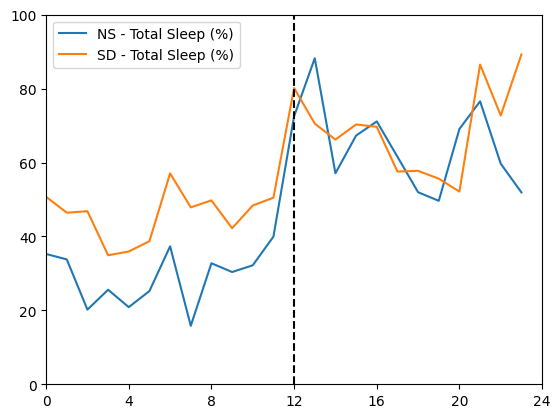

In [43]:
import matplotlib.pyplot as plt
plt.plot(df_NS['Wake_Percent'], label ='NS - Total Sleep (%)')
plt.plot(df_SD['Wake_Percent'], label ='SD - Total Sleep (%)')
plt.vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
plt.xlim(0,24)
plt.ylim(0,100)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

## Combined Data

In [2]:
df = pd.read_excel(r'D:\Xenium\Analysis\SD\Sleep-summary-no84.xlsx', sheet_name='forPython')

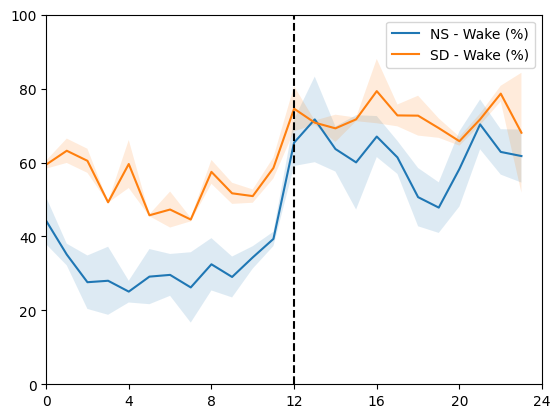

In [3]:
plt.plot(df['NS_W_A'], label ='NS - Wake (%)')
plt.plot(df['SD_W_A'], label ='SD - Wake (%)')

# plt.errorbar(x = df['ZT'], y = df['NS_W_A'], yerr=df['NS_W_SEM'], label ='NS - Wake (%)')
# plt.errorbar(x = df['ZT'], y = df['SD_W_A'], yerr=df['SD_W_SEM'], label ='SD - Wake (%)')
plt.vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
plt.fill_between(x= df['ZT'], y1 = df['NS_W_A'] - df['NS_W_SD'], y2 = df['NS_W_A'] + df['NS_W_SD'], alpha=.15)
plt.fill_between(x= df['ZT'], y1 = df['SD_W_A'] - df['SD_W_SD'], y2 = df['SD_W_A'] + df['SD_W_SD'], alpha=.15)
plt.xlim(0,24)
plt.ylim(0,100)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

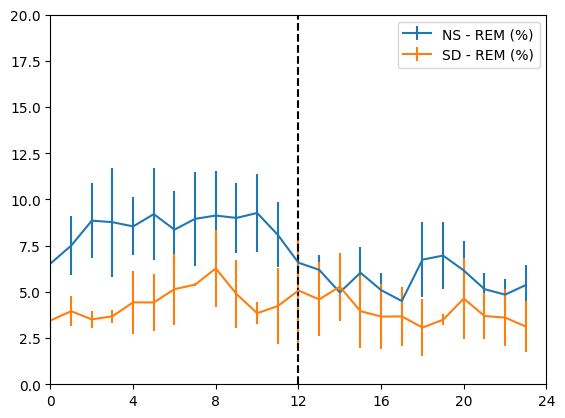

In [10]:
plt.errorbar(x = df['ZT'], y = df['NS_REM_A'], yerr=df['NS_REM_SEM'], label ='NS - REM (%)')
plt.errorbar(x = df['ZT'], y = df['SD_REM_A'], yerr=df['SD_REM_SEM'], label ='SD - REM (%)')
plt.vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
plt.xlim(0,24)
plt.ylim(0,20)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

In [142]:
import matplotlib.pyplot as plt
# import 
import matplotlib as mpl


# Ensure text remains editable in SVG

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects



# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

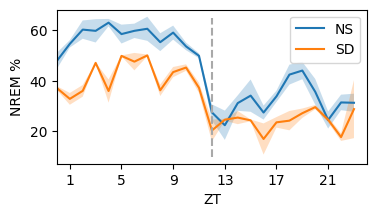

In [12]:
plt.figure(figsize=(4,2))
# plt.errorbar(x = df['ZT'], y = df['NS_NREM_A'], yerr=df['NS_NREM_SEM'], label ='NS - NREM (%)')
# plt.errorbar(x = df['ZT'], y = df['SD_NREM_A'], yerr=df['SD_NREM_SEM'], label ='SD - NREM (%)')
plt.plot(df['NS_NREM_A'], label ='NS')
plt.plot(df['SD_NREM_A'],label ='SD')
plt.fill_between(x= df['ZT'], y1 = df['NS_NREM_A'] - df['NS_W_SEM'], y2 = df['NS_NREM_A'] + df['NS_W_SEM'], alpha=.25)
plt.fill_between(x= df['ZT'], y1 = df['SD_NREM_A'] - df['SD_W_SEM'], y2 = df['SD_NREM_A'] + df['SD_W_SEM'], alpha=.25)
plt.vlines(x=12, ymin=10, ymax=65, linestyles='dashed', color = 'darkgrey')
plt.xlabel('ZT')
plt.ylabel("NREM %")
plt.xlim(0,24)
# plt.ylim(0,100)
plt.xticks([1,5,9,13,17,21])
plt.legend(loc = 'upper right')
plt.savefig('Gallery/sleep_NS-vs-SD.svg', format = 'svg', transparent = True)


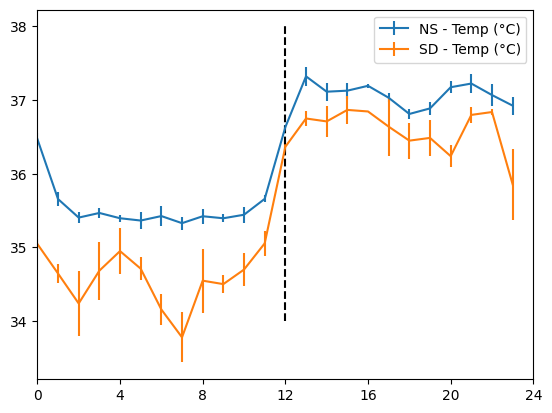

In [118]:
plt.errorbar(x = df['ZT'], y = df['NS_Temp_A'], yerr=df['NS_Temp_SEM'], label ='NS - Temp (°C)')
plt.errorbar(x = df['ZT'], y = df['SD_Temp_A'], yerr=df['SD_Temp_SEM'], label ='SD - Temp (°C)')
plt.vlines(x=12, ymin=34, ymax=38, linestyles='dashed', color = 'black')
plt.xlim(0,24)
# plt.ylim(0,20)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

Text(0.5, 0, 'ZT')

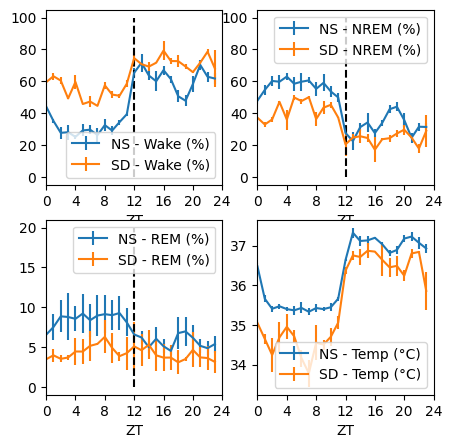

In [13]:
fig, ax = plt.subplots(2,2, figsize=(5,5))
ax = ax.flatten()

ax[0].errorbar(x = df['ZT'], y = df['NS_W_A'], yerr=df['NS_W_SEM'], label ='NS - Wake (%)')
ax[0].errorbar(x = df['ZT'], y = df['SD_W_A'], yerr=df['SD_W_SEM'], label ='SD - Wake (%)')
ax[0].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[0].set_xlim(0,24)
ax[0].set_xticks([0,4,8,12,16,20,24])
ax[0].legend(loc = 'lower right')

ax[1].errorbar(x = df['ZT'], y = df['NS_NREM_A'], yerr=df['NS_NREM_SEM'], label ='NS - NREM (%)')
ax[1].errorbar(x = df['ZT'], y = df['SD_NREM_A'], yerr=df['SD_NREM_SEM'], label ='SD - NREM (%)')
ax[1].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[1].set_xlim(0,24)
ax[1].set_xticks([0,4,8,12,16,20,24])
ax[1].legend(loc = 'upper right')

ax[2].errorbar(x = df['ZT'], y = df['NS_REM_A'], yerr=df['NS_REM_SEM'], label ='NS - REM (%)')
ax[2].errorbar(x = df['ZT'], y = df['SD_REM_A'], yerr=df['SD_REM_SEM'], label ='SD - REM (%)')
ax[2].vlines(x=12, ymin=0, ymax=20, linestyles='dashed', color = 'black')
ax[2].set_xlim(0,24)
ax[2].set_xticks([0,4,8,12,16,20,24])
ax[2].legend(loc = 'upper right')

ax[3].errorbar(x = df['ZT'], y = df['NS_Temp_A'], yerr=df['NS_Temp_SEM'], label ='NS - Temp (°C)')
ax[3].errorbar(x = df['ZT'], y = df['SD_Temp_A'], yerr=df['SD_Temp_SEM'], label ='SD - Temp (°C)')
ax[3].set_xlim(0,24)
ax[3].set_xticks([0,4,8,12,16,20,24])
ax[3].legend(loc = 'lower right')

ax[3].set_xlabel('ZT')
ax[2].set_xlabel('ZT')
ax[1].set_xlabel('ZT')
ax[0].set_xlabel('ZT')

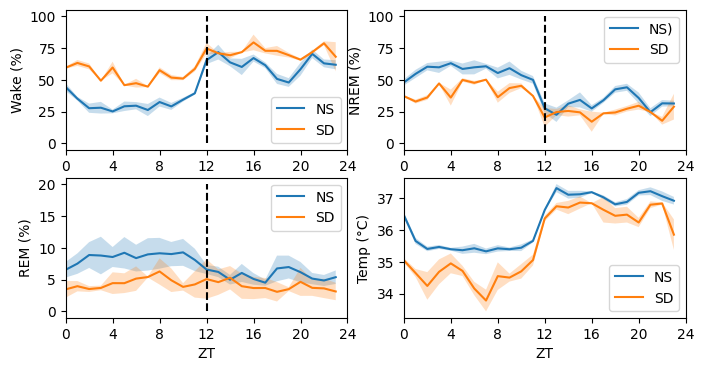

In [22]:
fig, ax = plt.subplots(2,2, figsize=(8,4))
ax = ax.flatten()

ax[0].plot(df['NS_W_A'], label ='NS')
ax[0].plot(df['SD_W_A'],  label ='SD')
ax[0].set_ylabel('Wake (%)')
ax[0].fill_between(x= df['ZT'], y1 = df['NS_W_A'] - df['NS_W_SEM'], y2 = df['NS_W_A'] + df['NS_W_SEM'], alpha=.25)
ax[0].fill_between(x= df['ZT'], y1 = df['SD_W_A'] - df['SD_W_SEM'], y2 = df['SD_W_A'] + df['SD_W_SEM'], alpha=.25)
ax[0].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[0].set_xlim(0,24)
ax[0].set_xticks([0,4,8,12,16,20,24])
ax[0].legend(loc = 'lower right')

ax[1].plot(df['NS_NREM_A'], label ='NS)')
ax[1].plot(df['SD_NREM_A'], label ='SD')
ax[1].set_ylabel('NREM (%)')
ax[1].fill_between(x= df['ZT'], y1 = df['NS_NREM_A'] - df['NS_NREM_SEM'], y2 = df['NS_NREM_A'] + df['NS_NREM_SEM'], alpha=.25)
ax[1].fill_between(x= df['ZT'], y1 = df['SD_NREM_A'] - df['SD_NREM_SEM'], y2 = df['SD_NREM_A'] + df['SD_NREM_SEM'], alpha=.25)
ax[1].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[1].set_xlim(0,24)
ax[1].set_xticks([0,4,8,12,16,20,24])
ax[1].legend(loc = 'upper right')

ax[2].plot(df['NS_REM_A'], label ='NS')
ax[2].plot(df['SD_REM_A'], label ='SD')
ax[2].set_ylabel('REM (%)')
ax[2].fill_between(x= df['ZT'], y1 = df['NS_REM_A'] - df['NS_REM_SEM'], y2 = df['NS_REM_A'] + df['NS_REM_SEM'], alpha=.25)
ax[2].fill_between(x= df['ZT'], y1 = df['SD_REM_A'] - df['SD_REM_SEM'], y2 = df['SD_REM_A'] + df['SD_REM_SEM'], alpha=.25)
ax[2].vlines(x=12, ymin=0, ymax=20, linestyles='dashed', color = 'black')
ax[2].set_xlim(0,24)
ax[2].set_xticks([0,4,8,12,16,20,24])
ax[2].legend(loc = 'upper right')

ax[3].plot(df['NS_Temp_A'], label ='NS')
ax[3].plot(df['SD_Temp_A'],  label ='SD')
ax[3].set_ylabel('Temp (°C)')
ax[3].fill_between(x= df['ZT'], y1 = df['NS_Temp_A'] - df['NS_Temp_SEM'], y2 = df['NS_Temp_A'] + df['NS_Temp_SEM'], alpha=.25)
ax[3].fill_between(x= df['ZT'], y1 = df['SD_Temp_A'] - df['SD_Temp_SEM'], y2 = df['SD_Temp_A'] + df['SD_Temp_SEM'], alpha=.25)
ax[3].set_xlim(0,24)
ax[3].set_xticks([0,4,8,12,16,20,24])
ax[3].legend(loc = 'lower right')

ax[3].set_xlabel('ZT')
ax[2].set_xlabel('ZT')
# ax[1].set_xlabel('ZT')
# ax[0].set_xlabel('ZT')

plt.savefig('Gallery/all_param_sleep.svg', format="svg",transparent = True)

KeyError: 'NS_Temp_SD'

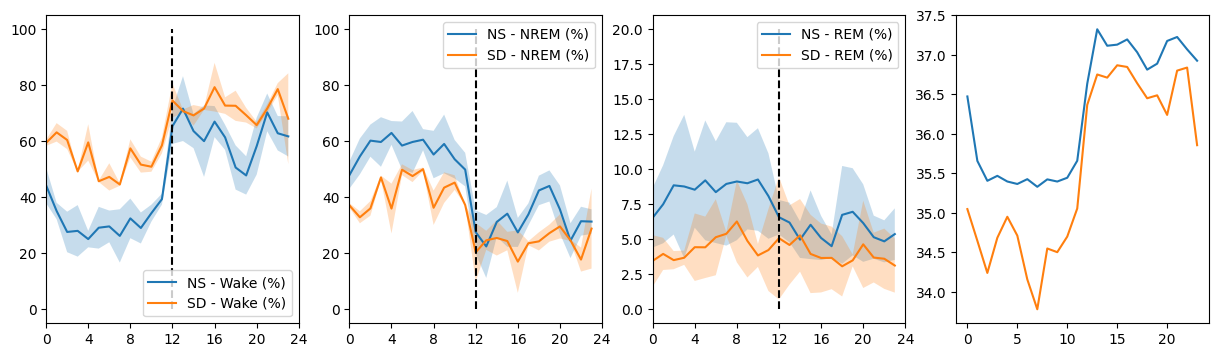

In [147]:
fig, ax = plt.subplots(1,4, figsize=(15,4))
ax = ax.flatten()

ax[0].plot(df['NS_W_A'], label ='NS - Wake (%)')
ax[0].plot(df['SD_W_A'],  label ='SD - Wake (%)')
ax[0].fill_between(x= df['ZT'], y1 = df['NS_W_A'] - df['NS_W_SD'], y2 = df['NS_W_A'] + df['NS_W_SD'], alpha=.25)
ax[0].fill_between(x= df['ZT'], y1 = df['SD_W_A'] - df['SD_W_SD'], y2 = df['SD_W_A'] + df['SD_W_SD'], alpha=.25)
ax[0].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[0].set_xlim(0,24)
ax[0].set_xticks([0,4,8,12,16,20,24])
ax[0].legend(loc = 'lower right')

ax[1].plot(df['NS_NREM_A'], label ='NS - NREM (%)')
ax[1].plot(df['SD_NREM_A'], label ='SD - NREM (%)')
ax[1].fill_between(x= df['ZT'], y1 = df['NS_NREM_A'] - df['NS_NREM_SD'], y2 = df['NS_NREM_A'] + df['NS_NREM_SD'], alpha=.25)
ax[1].fill_between(x= df['ZT'], y1 = df['SD_NREM_A'] - df['SD_NREM_SD'], y2 = df['SD_NREM_A'] + df['SD_NREM_SD'], alpha=.25)
ax[1].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[1].set_xlim(0,24)
ax[1].set_xticks([0,4,8,12,16,20,24])
ax[1].legend(loc = 'upper right')

ax[2].plot(df['NS_REM_A'], label ='NS - REM (%)')
ax[2].plot(df['SD_REM_A'], label ='SD - REM (%)')
ax[2].fill_between(x= df['ZT'], y1 = df['NS_REM_A'] - df['NS_REM_SD'], y2 = df['NS_REM_A'] + df['NS_REM_SD'], alpha=.25)
ax[2].fill_between(x= df['ZT'], y1 = df['SD_REM_A'] - df['SD_REM_SD'], y2 = df['SD_REM_A'] + df['SD_REM_SD'], alpha=.25)
ax[2].vlines(x=12, ymin=0, ymax=20, linestyles='dashed', color = 'black')
ax[2].set_xlim(0,24)
ax[2].set_xticks([0,4,8,12,16,20,24])
ax[2].legend(loc = 'upper right')

ax[3].plot(df['NS_Temp_A'], label ='NS - Temp (°C)')
ax[3].plot(df['SD_Temp_A'],  label ='SD - Temp (°C)')
ax[3].fill_between(x= df['ZT'], y1 = df['NS_Temp_A'] - df['NS_Temp_SD'], y2 = df['NS_Temp_A'] + df['NS_Temp_SD'], alpha=.25)
ax[3].fill_between(x= df['ZT'], y1 = df['SD_Temp_A'] - df['SD_Temp_SD'], y2 = df['SD_Temp_A'] + df['SD_Temp_SD'], alpha=.25)
ax[3].set_xlim(0,24)
ax[3].set_xticks([0,4,8,12,16,20,24])
ax[3].legend(loc = 'lower right')

ax[3].set_xlabel('ZT')
ax[2].set_xlabel('ZT')
ax[1].set_xlabel('ZT')
ax[0].set_xlabel('ZT')

# Sleep transition

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects
mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

In [4]:
df = pd.read_excel(r'E:\R\Sleep\output\2025-06-16_Normal-Sleep\1267843_2025-06-16_Normal-Sleep.xlsx', sheet_name='Sleep-transition-all')
df1 = pd.read_excel(r'E:\R\Sleep\output\2025-06-27_Sleep-Disruption_week1\1267843_2025-06-27_Sleep-Disruption_week1.xlsx', sheet_name='Sleep-transition-all')
df2 = pd.read_excel(r'E:\R\Sleep\output\2025-07-04_Sleep-Disruption_week2\1267843_2025-07-04_Sleep-Disruption_week2.xlsx', sheet_name='Sleep-transition-all')
df3= pd.read_excel(r'E:\R\Sleep\output\2025-07-11_Sleep-Disruption_week3\1267843_2025-07-11_Sleep-Disruption_week3.xlsx', sheet_name='Sleep-transition-all')
df4= pd.read_excel(r'E:\R\Sleep\output\2025-07-19_Sleep-Disruption_week4\1267843_2025-07-19_Sleep-Disruption_week4.xlsx', sheet_name='Sleep-transition-all')
dfr= pd.read_excel(r'E:\R\Sleep\output\2025-07-20_Sleep-rebound\1267843_2025-07-20_Sleep-rebound.xlsx', sheet_name='Sleep-transition-all')


In [5]:
df.index = df.States_name
df.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df1.index = df1.States_name
df1.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df2.index = df2.States_name
df2.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df3.index = df3.States_name
df3.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df4.index = df4.States_name
df4.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
dfr.index = dfr.States_name
dfr.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)

In [6]:
df.columns = df.index
df2.columns = df2.index
df1.columns = df1.index
df3.columns = df3.index
df4.columns = df4.index
dfr.columns = dfr.index

In [10]:
NS_df['average_df']

,ZT,Mean_W,Mean_P,Mean_c1,Mean_c2,Mean_c3,Mean_c4,Mean_c5,Mean_c6,Mean_W_percent,Mean_P_percent,Mean_c1_percent,Mean_c2_percent,Mean_c3_percent,Mean_c4_percent,Mean_c5_percent,Mean_c6_percent
0,W,67906.25,2051.00,437.50,678.25,410.25,959.00,843.75,769.75,90.445716,17.551866,5.770162,7.181453,5.316334,6.852984,7.139183,7.280293
1,P,2177.50,7309.25,541.00,938.75,447.50,1387.50,929.00,633.25,3.266560,37.683897,6.887453,9.737758,5.715717,10.254177,7.772930,6.179422
2,c1,430.00,638.00,3735.50,1057.50,1134.75,1264.75,568.00,392.25,0.714753,5.617177,33.083789,10.776762,13.089442,8.797044,4.409354,3.495125
3,c2,659.50,974.25,1071.00,3684.50,1010.50,1497.25,1219.00,777.50,1.040673,8.648681,13.016676,26.322717,11.942592,10.384738,9.718601,7.030757
4,c3,342.25,482.00,1244.75,986.75,3534.00,1045.00,942.25,710.00,0.558058,4.567686,15.027507,10.202797,31.663923,7.219683,7.487598,6.378525
5,c4,975.50,1388.25,1101.25,1482.00,980.25,6008.00,1982.00,1724.50,1.557383,11.771067,13.374839,15.002512,11.382825,32.350863,16.067110,15.926528
6,c5,814.00,917.00,655.00,1262.50,1035.25,1859.00,5281.75,2003.00,1.263768,8.416773,7.732047,12.786882,12.126849,12.898710,30.801428,18.395571
7,c6,743.75,605.00,435.75,804.25,735.50,1622.25,2062.75,5219.50,1.153090,5.742852,5.107527,7.989119,8.762317,11.241800,16.603797,35.313780


In [ ]:
NsForHM = SDW3_df['average_df']
NsForHM.drop(['ZT', "Mean_W", "Mean_P", "Mean_c1", "Mean_c2", "Mean_c3", "Mean_c4", "Mean_c5", "Mean_c6"], axis = 1, inplace=True)

KeyError: "['Mean_W', 'Mean_P', 'Mean_c1', 'Mean_c2', 'Mean_c3', 'Mean_c4', 'Mean_c5', 'Mean_c6'] not found in axis"

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(1, 0.5, 'W'),
  Text(1, 1.5, 'P'),
  Text(1, 2.5, 'c1'),
  Text(1, 3.5, 'c2'),
  Text(1, 4.5, 'c3'),
  Text(1, 5.5, 'c4'),
  Text(1, 6.5, 'c5'),
  Text(1, 7.5, 'c6')])

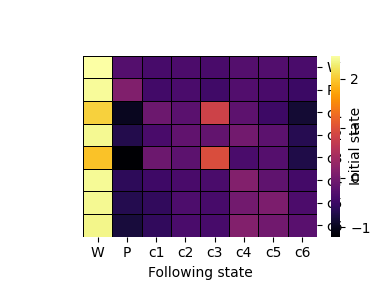

In [14]:
sns.clustermap(df1.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,3)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
# plt.savefig(f'Gallery/{today}/heatmap_transitions_NS.svg', format = "svg", dpi= 300, transparent = True)

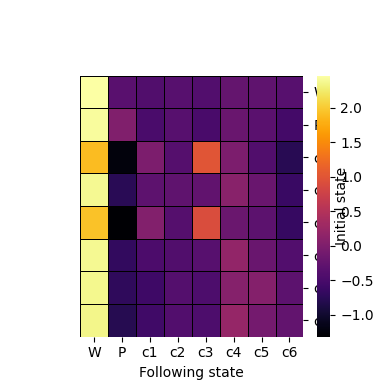

In [128]:
sns.clustermap(df1.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,4)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
plt.savefig('Gallery/heatmap_transitions_SDW1.svg', format = "svg", dpi= 300, transparent = True)

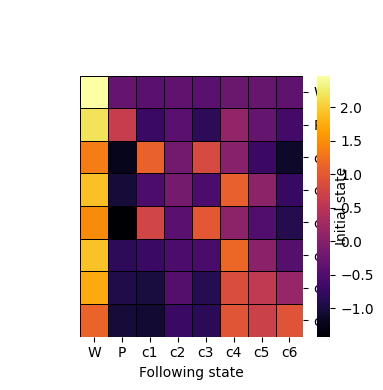

In [129]:
sns.clustermap(df2.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,4)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
plt.savefig('Gallery/heatmap_transitions_SDW2.svg', format = "svg", dpi= 300, transparent = True)

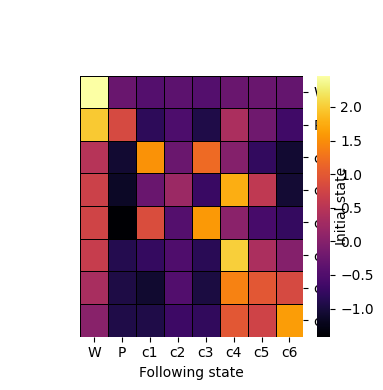

In [130]:
sns.clustermap(df3.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,4)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
plt.savefig('Gallery/heatmap_transitions_SDW3.svg', format = "svg", dpi= 300, transparent = True)

# Automatic average

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects
mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

print(f"pandas version: {pd.__version__}")

pandas version: 2.0.1


In [42]:
dict_exp = {
    "NS" : "2025-06-16_Normal-Sleep",
    "SDW1" : "2025-06-27_Sleep-disruption_week1",
    "SDW2" : "2025-07-04_Sleep-disruption_week2",
    "SDW3" : "2025-07-11_Sleep-disruption_week3",
    "SDW4" : "2025-07-19_Sleep-disruption_week4",
    "SR" : "2025-07-20_Sleep-rebound",
}

In [67]:
exp = "SDW4"
sheet_to_open = "ZT-Mean"

dir_input = r'E:\R\Sleep\output'

exp_folder_name = dict_exp[exp]
directory_expe = f'{dir_input}\{exp_folder_name}'

list_of_files = os.listdir(directory_expe)
list_of_files = [files for files in list_of_files if files[0]!="~"]
list_of_files

['1238359_2025-07-19_Sleep-Disruption_week4.xlsx',
 '1267843_2025-07-19_Sleep-Disruption_week4.xlsx',
 '1269984_2025-07-19_Sleep-Disruption_week4.xlsx']

In [68]:
dfs = []

for file in list_of_files:
    ID_mouse = file.split("_")[0]
    print(ID_mouse)
    df = pd.read_excel(f'{directory_expe}\{file}', sheet_name= sheet_to_open)
    ZT_list = df.iloc[:,0].astype(str)
    # df.iloc[:,0] = pd.Categorical(df.iloc[:,0])
    # df['subject'] = ID_mouse
    dfs.append(df)

ddf = dfs[0]
for n in range(1, len(dfs)):
    ddf = pd.concat([ddf,dfs[n]])

ddf

1238359
1267843
1269984


,ZT,Wake,NREM,REM,Total_Sleep,N_Wake,N_NREM,N_REM,Wake_Percent,NREM_Percent,...,Cluster3,Cluster4,Cluster5,Cluster6,Cluster1_Percent,Cluster2_Percent,Cluster3_Percent,Cluster4_Percent,Cluster5_Percent,Cluster6_Percent
0,0,841,213,7,220,1,1,1,79.264844,20.075401,...,17,50,58,52,2.816901,14.084507,7.981221,23.474178,27.230047,24.413146
1,1,776,334,12,346,1,1,1,69.162210,29.768271,...,20,104,46,111,8.982036,6.886228,5.988024,31.137725,13.772455,33.233533
2,2,967,703,23,726,1,1,1,57.117543,41.523922,...,14,291,129,187,5.974395,5.689900,1.991465,41.394026,18.349929,26.600284
3,3,782,378,19,397,1,1,1,66.327396,32.061069,...,15,158,57,76,8.730159,10.317460,3.968254,41.798942,15.079365,20.105820
4,4,961,545,28,573,1,1,1,62.646675,35.528031,...,14,246,96,105,7.339450,8.073394,2.568807,45.137615,17.614679,19.266055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,19,905,697,69,766,1,1,1,54.159186,41.711550,...,111,102,174,80,10.760402,22.238164,15.925395,14.634146,24.964132,11.477762
20,20,1132,490,58,548,1,1,1,67.380952,29.166667,...,81,73,135,46,6.122449,25.510204,16.530612,14.897959,27.551020,9.387755
21,21,1072,543,71,614,1,1,1,63.582444,32.206406,...,93,80,139,57,6.445672,25.598527,17.127072,14.732965,25.598527,10.497238
22,22,1267,322,64,386,1,1,1,76.648518,19.479734,...,49,54,68,61,4.968944,22.981366,15.217391,16.770186,21.118012,18.944099


In [69]:
average_df = pd.DataFrame(data = {"ZT":ZT_list})
std_df = pd.DataFrame(data = {"ZT":ZT_list})
sem_df = pd.DataFrame(data = {"ZT":ZT_list})

list_colums = list(ddf.columns)
list_colums.remove(ddf.columns[0])

for col in list_colums:
    average_df[f'Mean_{col}'] = ddf.groupby(ddf.index)[col].mean()
    std_df[f'Std_{col}'] = ddf.groupby(ddf.index)[col].std()
    sem_df[f'SEM_{col}'] = ddf.groupby(ddf.index)[col].std() / math.sqrt(len(ddf.groupby(ddf.index)))

combined = [average_df, std_df,sem_df]
list_of_files = ['average_df', 'std_df', 'sem_df']

writer = pd.ExcelWriter(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\{exp}_{sheet_to_open}_summ.xlsx', engine='xlsxwriter')
for j in range(0,len(combined)):
    combined[j].to_excel(writer, sheet_name=list_of_files[j], index=False)
writer.close()

In [70]:
average_df

,ZT,Mean_Wake,Mean_NREM,Mean_REM,Mean_Total_Sleep,Mean_N_Wake,Mean_N_NREM,Mean_N_REM,Mean_Wake_Percent,Mean_NREM_Percent,...,Mean_Cluster3,Mean_Cluster4,Mean_Cluster5,Mean_Cluster6,Mean_Cluster1_Percent,Mean_Cluster2_Percent,Mean_Cluster3_Percent,Mean_Cluster4_Percent,Mean_Cluster5_Percent,Mean_Cluster6_Percent
0,0,727.000000,479.000000,59.333333,538.333333,1.0,1.0,1.0,59.373103,36.436369,...,63.000000,98.666667,103.666667,100.000000,7.928267,14.035511,11.871805,21.440340,22.434022,22.290055
1,1,635.666667,779.666667,65.333333,845.000000,1.0,1.0,1.0,45.893178,50.014047,...,98.000000,180.000000,149.333333,172.666667,10.112885,11.599254,11.039791,24.993133,17.779134,24.475803
2,2,689.000000,758.000000,70.000000,828.000000,1.0,1.0,1.0,44.932100,50.384923,...,73.000000,245.000000,135.000000,156.666667,10.085384,9.323599,9.227259,32.688219,17.949949,20.725589
3,3,608.333333,791.666667,59.666667,851.333333,1.0,1.0,1.0,43.764664,52.414369,...,75.333333,222.333333,133.000000,154.666667,11.532459,13.156916,8.439076,30.920347,16.419333,19.531869
4,4,658.666667,803.333333,60.000000,863.333333,1.0,1.0,1.0,42.798893,53.376008,...,66.000000,250.000000,139.333333,168.333333,10.858146,10.556580,7.515704,33.017535,17.395319,20.656715
5,5,608.000000,649.333333,72.000000,721.333333,1.0,1.0,1.0,47.162696,47.792768,...,52.333333,224.333333,108.000000,119.333333,12.737458,9.466699,7.625917,35.665156,15.642819,18.861952
6,6,687.000000,537.333333,64.000000,601.333333,1.0,1.0,1.0,52.943681,42.481417,...,40.000000,191.333333,89.000000,98.000000,13.180191,9.632222,6.722262,36.525978,16.213488,17.725860
7,7,677.000000,811.000000,66.333333,877.333333,1.0,1.0,1.0,42.768801,52.973004,...,77.000000,260.666667,132.333333,145.666667,11.832683,11.566668,8.261304,33.515290,16.667800,18.156255
8,8,667.000000,804.666667,102.666667,907.333333,1.0,1.0,1.0,42.832700,50.799748,...,68.333333,261.000000,142.000000,118.666667,13.368845,12.200330,8.209139,33.042003,17.857055,15.322629
9,9,831.333333,662.666667,73.666667,736.333333,1.0,1.0,1.0,52.280835,43.032490,...,70.000000,182.000000,124.333333,97.666667,13.220000,15.155043,10.423747,27.830251,18.692250,14.678708


## Import dfs

In [9]:
sheet_to_open = "Sleep-transition-all"

NS_df = pd.read_excel(fr'data\Sleep-distruption-exp\NS_{sheet_to_open}_summ.xlsx', sheet_name=None)
SDW1_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW1_{sheet_to_open}_summ.xlsx', sheet_name=None)
SDW2_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW2_{sheet_to_open}_summ.xlsx', sheet_name=None)
SDW3_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW3_{sheet_to_open}_summ.xlsx', sheet_name=None)
SDW4_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW4_{sheet_to_open}_summ.xlsx', sheet_name=None)
SR_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SR_{sheet_to_open}_summ.xlsx', sheet_name=None)

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\R\\SleepAnalysis\\data\\Sleep-distruption-exp\\SDW2_Sleep-transition-all_summ.xlsx'

In [22]:
NS_df['average_df'].columns

Index(['ZT', 'Mean_EMG_z_Mean', 'Mean_EMG_z_N', 'Mean_Delta_z_Mean',
       'Mean_Delta_z_N', 'Mean_Theta_z_Mean', 'Mean_Theta_z_N',
       'Mean_Alpha_z_Mean', 'Mean_Alpha_z_N', 'Mean_Sigma_z_Mean',
       'Mean_Sigma_z_N', 'Mean_Beta_z_Mean', 'Mean_Beta_z_N',
       'Mean_EEG_z_Mean', 'Mean_EEG_z_N', 'Mean_Temp_Mean', 'Mean_Temp_N',
       'Mean_Activity_Mean', 'Mean_Activity_N'],
      dtype='object')

## Plots

In [72]:
plt.plot(average_df['Mean_Light_phase_min'], label = "Wake")
plt.fill_between(x=std_df.index,
                 y1=average_df['Mean_Light_phase_min']-std_df['Std_Light_phase_min'],
                 y2 =average_df['Mean_Light_phase_min']+std_df['Std_Light_phase_min'],
                 alpha=0.25)
plt.plot(average_df['Mean_NREM_Percent'], label = "NREM")
plt.fill_between(x=std_df.index,
                 y1=average_df['Mean_NREM_Percent']-std_df['Std_NREM_Percent'],
                 y2 =average_df['Mean_NREM_Percent']+std_df['Std_NREM_Percent'],
                 alpha=0.25)
plt.plot(average_df['Mean_REM_Percent'], label = "REM")
plt.fill_between(x=std_df.index,
                 y1=average_df['Mean_REM_Percent']-std_df['Std_REM_Percent'],
                 y2 =average_df['Mean_REM_Percent']+std_df['Std_REM_Percent'],
                 alpha=0.25)
plt.xlabel('ZT')
plt.ylabel('Percentage')
plt.xticks([0,4,8,12,16,20,24])
plt.vlines(x=12,ymin=0,ymax = 80, linestyles='dashed', color = "grey")
plt.xlim(0,24)
plt.ylim(0)
plt.legend()
plt.title(f'{exp}')
# plt.savefig(f'Gallery/{exp}_all.svg', format = 'svg',transparent =True)

KeyError: 'Mean_Light_phase_min'

### Three Graphs

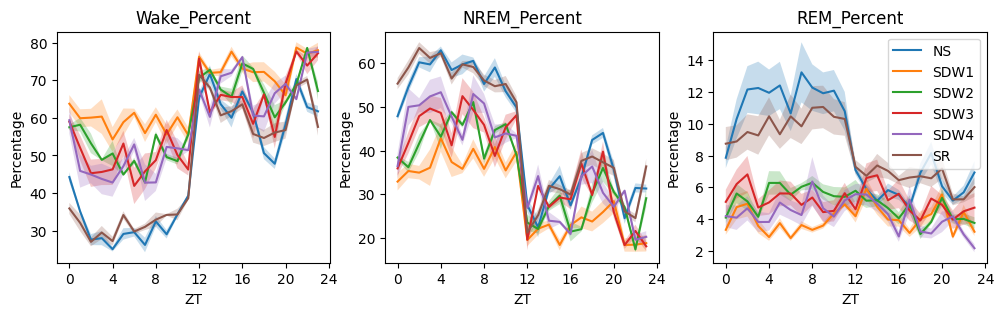

In [74]:
vari_plt = ['Wake_Percent', 'NREM_Percent', 'REM_Percent']

fig, ax = plt.subplots(1,3, figsize=(12,3), sharex=True, sharey=False)

for n in range(len(vari_plt)):
    ax[n].plot(NS_df['average_df'][f'Mean_{vari_plt[n]}'], label = "NS")
    ax[n].plot(SDW1_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW1")
    ax[n].plot(SDW2_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW2")
    ax[n].plot(SDW3_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW3")
    ax[n].plot(SDW4_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW4")
    ax[n].plot(SR_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SR")
    ax[n].set_xlabel('ZT')
    ax[n].set_ylabel('Percentage')
    ax[n].set_xticks([0,4,8,12,16,20,24])
    # ax[n].vlines(x=12,ymin=0,ymax = 80, linestyles='dashed', color = "grey")
    ax[n].set_title(vari_plt[n])

    ax[n].fill_between(x = NS_df['average_df']['ZT'],
                    y1 = NS_df['average_df'][f'Mean_{vari_plt[n]}']-NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = NS_df['average_df'][f'Mean_{vari_plt[n]}']+NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW1_df['average_df']['ZT'],
                    y1 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']-SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']+SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW2_df['average_df']['ZT'],
                    y1 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']-SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']+SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW3_df['average_df']['ZT'],
                    y1 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']-SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']+SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW4_df['average_df']['ZT'],
                    y1 = SDW4_df['average_df'][f'Mean_{vari_plt[n]}']-SDW4_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW4_df['average_df'][f'Mean_{vari_plt[n]}']+SDW4_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SR_df['average_df']['ZT'],
                    y1 = SR_df['average_df'][f'Mean_{vari_plt[n]}']-SR_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SR_df['average_df'][f'Mean_{vari_plt[n]}']+SR_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.savefig(fr'Gallery\\all-recording_{vari_plt}.svg', format = 'svg',transparent = True)

### Six graphs

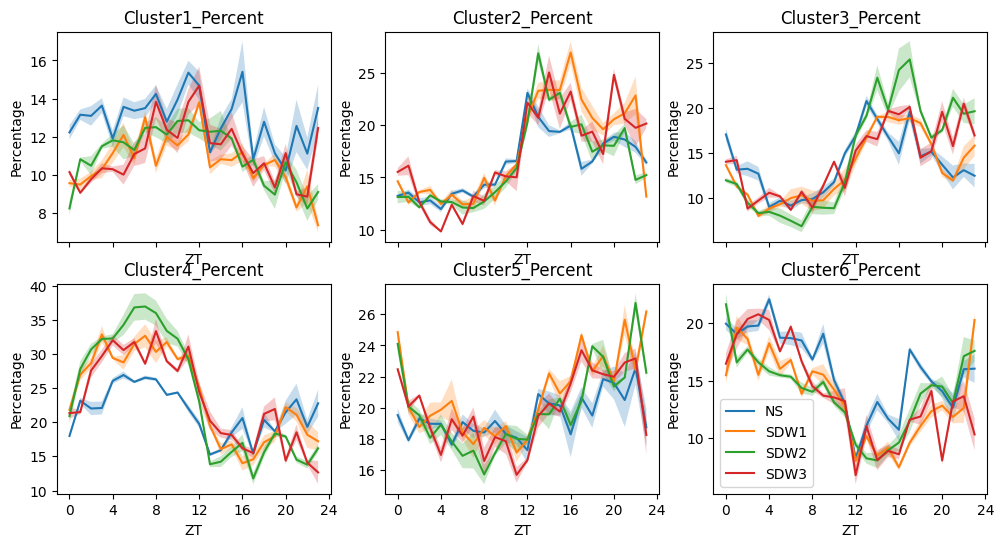

In [24]:
# vari_plt = ['Wake_Percent', 'NREM_Percent', 'REM_Percent']
vari_plt = ['Cluster1_Percent',
       'Cluster2_Percent', 'Cluster3_Percent',
       'Cluster4_Percent', 'Cluster5_Percent',
       'Cluster6_Percent']

fig, ax = plt.subplots(2,3, figsize=(12,6), sharex=True, sharey=False)
ax = ax.flatten()

for n in range(len(vari_plt)):
    ax[n].plot(NS_df['average_df'][f'Mean_{vari_plt[n]}'], label = "NS")
    ax[n].plot(SDW1_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW1")
    ax[n].plot(SDW2_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW2")
    ax[n].plot(SDW3_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW3")
    ax[n].set_xlabel('ZT')
    ax[n].set_ylabel('Percentage')
    ax[n].set_xticks([0,4,8,12,16,20,24])
    # ax[n].vlines(x=12,ymin=0,ymax = 80, linestyles='dashed', color = "grey")
    ax[n].set_title(vari_plt[n])

    ax[n].fill_between(x = NS_df['average_df']['ZT'],
                    y1 = NS_df['average_df'][f'Mean_{vari_plt[n]}']-NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = NS_df['average_df'][f'Mean_{vari_plt[n]}']+NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW1_df['average_df']['ZT'],
                    y1 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']-SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']+SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW2_df['average_df']['ZT'],
                    y1 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']-SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']+SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW3_df['average_df']['ZT'],
                    y1 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']-SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']+SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.savefig('Gallery\\all-recording_NREM-clusters.svg', format = 'svg',transparent = True)

### One graph

In [23]:
NS_df['average_df'].columns

Index(['ZT', 'Mean_EMG_z_Mean', 'Mean_EMG_z_N', 'Mean_Delta_z_Mean',
       'Mean_Delta_z_N', 'Mean_Theta_z_Mean', 'Mean_Theta_z_N',
       'Mean_Alpha_z_Mean', 'Mean_Alpha_z_N', 'Mean_Sigma_z_Mean',
       'Mean_Sigma_z_N', 'Mean_Beta_z_Mean', 'Mean_Beta_z_N',
       'Mean_EEG_z_Mean', 'Mean_EEG_z_N', 'Mean_Temp_Mean', 'Mean_Temp_N',
       'Mean_Activity_Mean', 'Mean_Activity_N'],
      dtype='object')

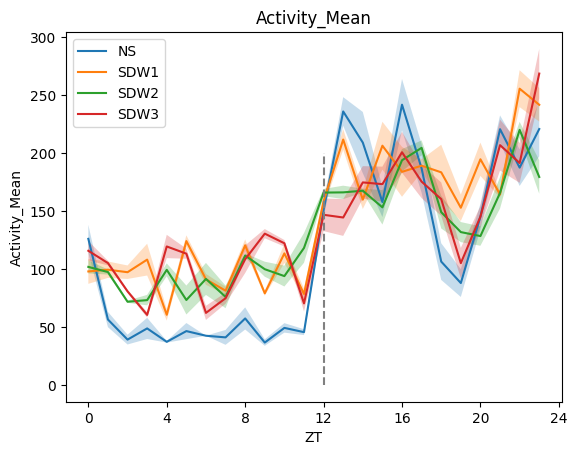

In [28]:
vari_plt = 'Activity_Mean'

ax = plt.subplot()


plt.plot(NS_df['average_df'][f'Mean_{vari_plt}'], label = "NS")
plt.plot(SDW1_df['average_df'][f'Mean_{vari_plt}'], label = "SDW1")
plt.plot(SDW2_df['average_df'][f'Mean_{vari_plt}'], label = "SDW2")
plt.plot(SDW3_df['average_df'][f'Mean_{vari_plt}'], label = "SDW3")
plt.xlabel('ZT')
plt.ylabel(vari_plt)
plt.xticks([0,4,8,12,16,20,24])
plt.vlines(x=12,ymin=0,ymax = 200, linestyles='dashed', color = "grey")
plt.title(vari_plt)

plt.fill_between(x = NS_df['average_df']['ZT'],
                y1 = NS_df['average_df'][f'Mean_{vari_plt}']-NS_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = NS_df['average_df'][f'Mean_{vari_plt}']+NS_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
plt.fill_between(x = SDW1_df['average_df']['ZT'],
                y1 = SDW1_df['average_df'][f'Mean_{vari_plt}']-SDW1_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = SDW1_df['average_df'][f'Mean_{vari_plt}']+SDW1_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
plt.fill_between(x = SDW2_df['average_df']['ZT'],
                y1 = SDW2_df['average_df'][f'Mean_{vari_plt}']-SDW2_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = SDW2_df['average_df'][f'Mean_{vari_plt}']+SDW2_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
plt.fill_between(x = SDW3_df['average_df']['ZT'],
                y1 = SDW3_df['average_df'][f'Mean_{vari_plt}']-SDW3_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = SDW3_df['average_df'][f'Mean_{vari_plt}']+SDW3_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.savefig(fr'Gallery\\all-recording_{vari_plt}.svg', format = 'svg',transparent = True, dpi=300)

### Two graphs

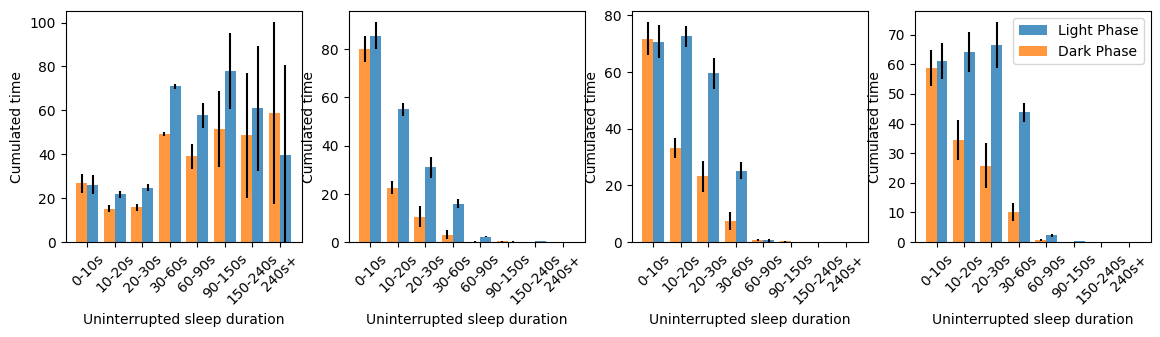

In [31]:
fig, ax = plt.subplots (1,4,figsize=(14,3), sharex=True, sharey=False)

ax[0].bar(x = NS_df['average_df']["ZT"], height = NS_df['average_df']['Mean_Light_phase_h'], yerr = NS_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)

ax[0].bar(x = NS_df['average_df']["ZT"], height = NS_df['average_df']['Mean_Dark_phase_h'], yerr = NS_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)

ax[0].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[0].set_ylim(0)
ax[0].set_ylabel('Cumulated time')
ax[0].set_xlabel('Uninterrupted sleep duration')

ax[1].bar(x = SDW1_df['average_df']["ZT"], height = SDW1_df['average_df']['Mean_Light_phase_h'], yerr = SDW1_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)
ax[1].bar(x = SDW1_df['average_df']["ZT"], height = SDW1_df['average_df']['Mean_Dark_phase_h'], yerr = SDW1_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)
ax[1].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[1].set_ylabel('Cumulated time')
ax[1].set_xlabel('Uninterrupted sleep duration')

ax[2].bar(x = SDW2_df['average_df']["ZT"], height = SDW2_df['average_df']['Mean_Light_phase_h'], yerr = SDW2_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)
ax[2].bar(x = SDW2_df['average_df']["ZT"], height = SDW2_df['average_df']['Mean_Dark_phase_h'], yerr = SDW2_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)
ax[2].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[2].set_ylabel('Cumulated time')
ax[2].set_xlabel('Uninterrupted sleep duration')

ax[3].bar(x = SDW3_df['average_df']["ZT"], height = SDW3_df['average_df']['Mean_Light_phase_h'], yerr = SDW3_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)
ax[3].bar(x = SDW3_df['average_df']["ZT"], height = SDW3_df['average_df']['Mean_Dark_phase_h'], yerr = SDW3_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)
ax[3].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[3].set_ylabel('Cumulated time')
ax[3].set_xlabel('Uninterrupted sleep duration')

ax[3].legend()
ax[2].set_ylim(0)

plt.savefig('Gallery\\bouts_duration_all.svg', format = 'svg', transparent = True, dpi= 300)

# Stat

In [60]:
import numpy as np 
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from IPython.display import clear_output

## ZT + Condition Two Way ANOVA

In [55]:
dict_exp = {
    "NS" : "2025-06-16_Normal-Sleep",
    "SDW1" : "2025-06-27_Sleep-disruption_week1",
    "SDW2" : "2025-07-04_Sleep-disruption_week2",
    "SDW3" : "2025-07-11_Sleep-disruption_week3",
    "SDW4" : "2025-07-19_Sleep-disruption_week4",
    "SR" : "2025-07-20_Sleep-rebound",
}

In [75]:
exp = dict_exp.keys()

sheet_to_open = "ZT-Mean"

dir_input = r'E:\R\Sleep\output'
dfs = []
for ex in exp:
    print(ex)
    exp_folder_name = dict_exp[ex]
    directory_expe = f'{dir_input}\{exp_folder_name}'

    list_of_files = os.listdir(directory_expe)
    list_of_files = [files for files in list_of_files if files[0]!="~"]
    list_of_files

    

    for file in list_of_files:
        ID_mouse = file.split("_")[0]
        print(ID_mouse)
        df = pd.read_excel(f'{directory_expe}\{file}', sheet_name= sheet_to_open)
        ZT_list = df.iloc[:,0].astype(str)
        df['Condition'] = ex
        # df.iloc[:,0] = pd.Categorical(df.iloc[:,0])
        # df['subject'] = ID_mouse
        dfs.append(df)
    clear_output()

ddf = dfs[0]
for n in range(1, len(dfs)):
    ddf = pd.concat([ddf,dfs[n]])

ddf

,ZT,Wake,NREM,REM,Total_Sleep,N_Wake,N_NREM,N_REM,Wake_Percent,NREM_Percent,...,Cluster4,Cluster5,Cluster6,Cluster1_Percent,Cluster2_Percent,Cluster3_Percent,Cluster4_Percent,Cluster5_Percent,Cluster6_Percent,Condition
0,0,797.000000,813.750000,77.750000,891.500000,4,4,4,47.201658,48.193663,...,141.500000,134.750000,148.750000,12.227343,13.517665,22.027650,17.388633,16.559140,18.279570,NS
1,1,624.750000,1001.750000,86.250000,1088.000000,4,4,4,36.476427,58.487812,...,253.250000,168.250000,156.000000,12.977290,14.100324,15.273272,25.280759,16.795608,15.572748,NS
2,2,444.750000,1026.250000,78.750000,1105.000000,4,4,4,28.698177,66.220358,...,159.250000,223.250000,212.000000,9.549330,13.252132,19.269184,15.517661,21.753959,20.657734,NS
3,3,702.333333,946.000000,63.666667,1009.666667,3,3,3,41.024143,55.257009,...,143.666667,199.666667,179.000000,11.486963,15.292459,18.005638,15.186751,21.106413,18.921776,NS
4,4,472.666667,1154.000000,97.000000,1251.000000,3,3,3,27.422162,66.950300,...,330.666667,221.666667,288.666667,8.809936,12.651646,5.661467,28.653957,19.208550,25.014443,NS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,19,722.111111,715.555556,147.666667,863.222222,9,9,9,45.549481,45.135969,...,132.111111,157.777778,100.666667,10.031056,20.807453,14.580745,18.462733,22.049689,14.068323,SR
20,20,831.111111,587.777778,165.222222,753.000000,9,9,9,52.465456,37.104580,...,109.111111,132.333333,79.333333,9.451796,21.833648,14.139887,18.563327,22.514178,13.497164,SR
21,21,1096.222222,374.666667,110.777778,485.444444,9,9,9,69.308044,23.688093,...,67.444444,90.000000,53.000000,7.354686,22.153025,14.323843,18.001186,24.021352,14.145907,SR
22,22,1166.222222,318.444444,95.000000,413.444444,9,9,9,73.827108,20.158965,...,52.444444,78.444444,51.888889,7.431961,19.609211,15.561759,16.468946,24.633636,16.294487,SR


In [76]:
col_to_analyse = "REM_Percent" ### Can only be done with col names without space

# ddf.groupby('Condition')[col_to_analyse].mean()
print(ddf[ddf['ZT']<12].groupby('Condition')[col_to_analyse].mean())
print(ddf[ddf['ZT']>=12].groupby('Condition')[col_to_analyse].mean())

Condition
NS      11.487967
SDW1     3.824948
SDW2     5.497216
SDW3     5.331482
SDW4     4.573978
SR       9.939644
Name: REM_Percent, dtype: float64
Condition
NS      6.096486
SDW1    4.195811
SDW2    4.487410
SDW3    5.050021
SDW4    4.009061
SR      6.536806
Name: REM_Percent, dtype: float64


In [77]:
model = ols(f'{col_to_analyse} ~ C(Condition) + C(ZT) + C(Condition):C(ZT)', data=ddf).fit()
anova_result = sm.stats.anova_lm(model, type=2)
anova_result

,df,sum_sq,mean_sq,F,PR(>F)
C(Condition),5.0,1722.341301,344.468260,24.522264,7.975584e-21
C(ZT),23.0,534.469145,23.237789,1.654269,3.181533e-02
C(Condition):C(ZT),115.0,757.709219,6.588776,0.469047,9.999976e-01
Residual,312.0,4382.715102,14.047164,NaN,NaN


In [78]:
import scikit_posthocs as sp
print(col_to_analyse)
sp.posthoc_tukey(ddf, val_col=col_to_analyse, group_col='Condition',
                     # p_adjust='fdr_bh'
                     )


REM_Percent


,NS,SDW1,SDW2,SDW3,SDW4,SR
NS,1.000000e+00,0.000000e+00,3.350898e-10,3.102488e-09,8.104628e-15,9.176181e-01
SDW1,0.000000e+00,1.000000e+00,5.597102e-01,3.471428e-01,9.969889e-01,5.529799e-11
SDW2,3.350898e-10,5.597102e-01,1.000000e+00,9.994383e-01,8.444124e-01,1.033637e-06
SDW3,3.102488e-09,3.471428e-01,9.994383e-01,1.000000e+00,6.519811e-01,5.816551e-06
SDW4,8.104628e-15,9.969889e-01,8.444124e-01,6.519811e-01,1.000000e+00,1.139674e-09
SR,9.176181e-01,5.529799e-11,1.033637e-06,5.816551e-06,1.139674e-09,1.000000e+00
